# Lab 2: Coordinate Transformations Using Spatial Math

**Course:** 24AM3510 - Foundations of Robotics and Intelligent Systems  
**Mapped course outcome:** CO2  
**Lab focus:** Practical use of Peter Corke's Spatial Math and Robotics Toolbox

## Purpose
This lab develops toolbox fluency for later projects. Matrix derivations belong to theory tutorials; here you will create, compose, plot, invert, and apply 2D and 3D poses using native toolbox objects.

> Complete Experiments 1-4 after Lecture 10. Complete Experiment 5 and Assignment Problem 2 only after Lecture 11 on coordinate transformations.


## Learning objectives
By the end of this lab, you should be able to:
1. Create and visualise 2D rotations and poses.
2. Create and visualise 3D rotations and poses.
3. Use a pose to express a point in another frame.
4. Use the inverse pose to return a point to its local frame.
5. Explain the role of coordinate frames in a robot project.

## Toolbox vocabulary
| Tool | What it does | Important inputs |
|---|---|---|
| SE2() | 2D world pose at origin | none |
| SE2(x, y) | 2D translation pose | x, y coordinates |
| SE2.Rot(theta, unit='deg') | planar rotation pose | theta angle; unit in degrees |
| SE3() | 3D world pose at origin | none |
| SE3.Trans(x, y, z) | 3D translation pose | x, y, z coordinates |
| SE3.Rz(theta, unit='deg') | 3D rotation about z | theta angle; unit in degrees |
| T1 * T2 | compose two toolbox poses | poses T1 and T2 |
| T * p | express point p in the destination frame | pose T, point p |
| T.inv() | inverse of pose T | pose T |
| T.plot(...) | visualise a coordinate frame | frame label, colour, new figure |

We use NumPy only to write point coordinates. NumPy will not be used to construct or multiply transformation matrices in this lab.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from spatialmath import SE2, SE3

np.set_printoptions(precision=3, suppress=True)
print('Environment ready.')


Environment ready.


# Experiment 1 - 2D rotation

## Function: SE2.Rot(theta, unit='deg')
Creates a 2D rotation pose about the current origin. theta is the rotation angle. unit='deg' means the angle is written in degrees. Positive rotation is counter-clockwise.

The native plot function displays the axes of the resulting frame. Before running, predict where the x-axis of frame {A} points after +90 degrees.


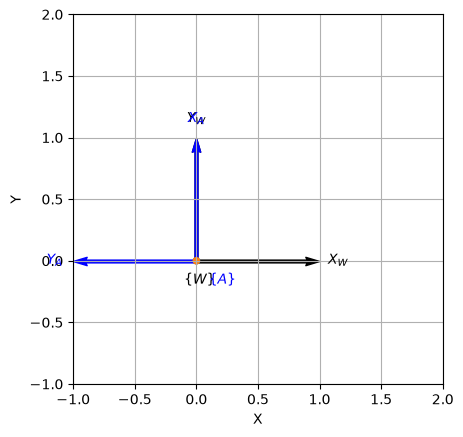

In [2]:
W = SE2()
A = SE2.Rot(90, unit='deg')

W.plot(frame='W', color='black', new=True)
A.plot(frame='A', color='blue', new=False)
plt.axis([-1, 2, -1, 2])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()


**Try it:** Change +90 to -90. Predict first, then state how the directions of the x- and y-axes changed.


# Experiment 2 - 2D homogeneous pose

## Function: SE2(x, y)
Creates a 2D translation pose with origin at (x, y).

## Operator: T1 * T2
Composes two native pose objects. In the code below, frame {B} is translated to (0.8, 0.4) and rotated +90 degrees. The toolbox performs the homogeneous-transformation composition internally.

## Operator: T * p
Applies pose T to point p. p_B is the local coordinate of a point expressed in frame {B}. T_W_B * p_B expresses the same physical point in world frame {W}.


Point in frame B: [0.2 0. ]
Same point in world frame W: [[0.8]
 [0.6]]


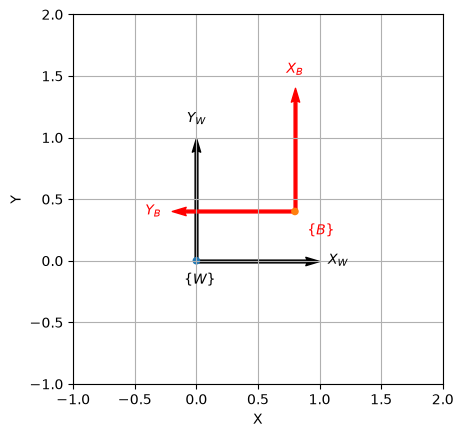

In [3]:
T_W_B = SE2(0.8, 0.4) * SE2.Rot(90, unit='deg')
p_B = np.array([0.2, 0.0])
p_W = T_W_B * p_B

print('Point in frame B:', p_B)
print('Same point in world frame W:', p_W)

W.plot(frame='W', color='black', new=True)
T_W_B.plot(frame='B', color='red', new=False)
plt.axis([-1, 2, -1, 2])
plt.gca().set_aspect('equal')
plt.grid()
plt.show()


**Try it:** Change the position and rotation of {B}, then change p_B. Describe how each change affects the displayed frame or point coordinates.


# Experiment 3 - 3D rotation

## Function: SE3.Rz(theta, unit='deg')
Creates a 3D rotation about the positive z-axis. theta is the rotation angle; unit='deg' specifies degrees. The origin stays fixed while the x- and y-axes rotate.

Before running, predict which axis stays in the same direction after rotation about z.


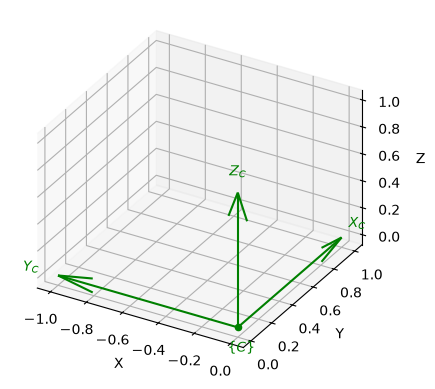

In [4]:
C = SE3.Rz(90, unit='deg')
C.plot(frame='C', color='green', new=True)
plt.show()


# Experiment 4 - 3D homogeneous pose

## Function: SE3.Trans(x, y, z)
Creates a 3D translation pose. x, y, and z give the new frame origin.

The code composes translation and rotation to form frame {D}. It then expresses a point p_D in world coordinates, using only toolbox pose operations.


Point in frame D: [0.4 0.  0. ]
Same point in world frame W: [[0.6]
 [0.6]
 [0.3]]


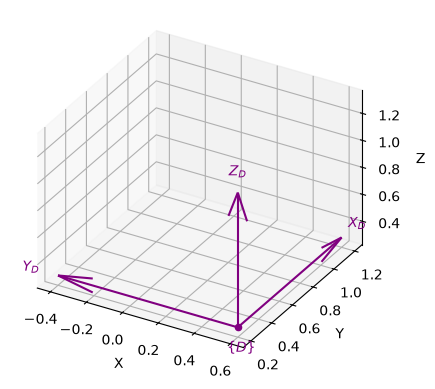

In [5]:
T_W_D = SE3.Trans(0.6, 0.2, 0.3) * SE3.Rz(90, unit='deg')
p_D = np.array([0.4, 0.0, 0.0])
p_W = T_W_D * p_D

print('Point in frame D:', p_D)
print('Same point in world frame W:', p_W)

T_W_D.plot(frame='D', color='purple', new=True)
plt.show()


# Experiment 5 - Coordinate transformation between frames

> Complete this section after Lecture 11.

## Function: T.inv()
Returns the inverse of pose T. If T_W_D converts coordinates from {D} to {W}, then T_W_D.inv() converts coordinates from {W} back to {D}.

The code returns the world point to its original local coordinates. Verify that p_D_recovered agrees with p_D.


In [6]:
T_D_W = T_W_D.inv()
p_D_recovered = T_D_W * p_W

print('Recovered point in frame D:', p_D_recovered)
print('Original point in frame D:', p_D)
print('Recovered correctly?', np.allclose(p_D_recovered.flatten(), p_D))


Recovered point in frame D: [[0.4]
 [0. ]
 [0. ]]
Original point in frame D: [0.4 0.  0. ]
Recovered correctly? True


# Assignment
Complete both problems in this notebook. Keep figures and outputs visible; answer interpretation questions in Markdown cells. You must be able to explain every pose operation you use.

## Problem 1 - 2D warehouse object
A package frame {P} is located at (1.0, -0.5) and is rotated +90 degrees relative to world frame {W}. A barcode is at p_P = (0.15, 0.05) in the package frame.

1. Create T_W_P using SE2 and SE2.Rot.
2. Plot {W} and {P}.
3. Compute barcode coordinates in the world frame using T_W_P * p_P.
4. Change the rotation to -90 degrees and explain the visual and numerical difference.


In [ ]:
# Assignment Problem 1 - write your solution here


## Problem 2 - 3D robot workcell
Complete after Lecture 11. A camera frame {Cam} is translated by (0.4, 0.2, 0.8) and rotated +90 degrees about z relative to {W}. A detected object has p_Cam = (0.1, 0.0, 0.2) in the camera frame.

1. Create T_W_Cam using SE3.Trans and SE3.Rz.
2. Plot {Cam}.
3. Express the detected object in world coordinates.
4. Use T_W_Cam.inv() to recover the object coordinates in the camera frame.
5. Explain why a robot requires this conversion before attempting to grasp the object.


In [ ]:
# Assignment Problem 2 - write your solution here


## Submission checklist
- [ ] Course virtual-environment kernel selected
- [ ] All cells execute without errors
- [ ] Both assignments include code, output, and interpretation
- [ ] Notebook filename contains name and USN
